<a href="https://colab.research.google.com/github/nhjung74/paper/blob/main/factor_rl_portfolio_20250706_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 딥러닝 처리 환경 requirements
g_drive = False
mac_gpu = False
# colab
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False
# print(IN_COLAB)

if IN_COLAB:
    print('colab......')
    g_drive = True
    # google drive setting
    #from google.colab import drive
    #drive.mount('/content/drive')
    #import os
    #try:
    #    import transformers, emoji, soynlp, pytorch_lightning
    #except:
    #    ! pip install -U -q transformers emoji soynlp pytorch-lightning snoop wandb sklearn seaborn pandas numpy
    # restart runtime
    #os.kill(os.getpid(), 9)
elif IN_COLAB==False:
    print('not colab')
    g_drive = False
    #import os
    #try:
    #    import transformers, emoji, soynlp, pytorch_lightning
    #except:
    #    ! pip install -U -q transformers emoji soynlp pytorch-lightning snoop wandb sklearn seaborn pandas numpy
    #    ! pip install -q torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu116

print('g_drive=',g_drive)

colab......
g_drive= True


In [2]:
import platform

platform.system()

'Linux'

In [3]:
os_type = platform.system()

In [4]:
# Os 종류를 확인한다.
if os_type == 'Darwin':
    mac_gpu = True
else:
    mac_gpu = False
print('mac_gpu=',mac_gpu)

mac_gpu= False


In [5]:
if g_drive == True:
  !pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
if g_drive == True:
  !pip install PyPortfolioOpt

In [ ]:
if g_drive == True:
  !pip install shimmy>=0.2.1

In [ ]:
if g_drive == True:
  !pip install stable-baselines3

In [ ]:
# 필요한 패키지 불러오기
import os
import math
import time
import datetime

In [ ]:
# 기본 디렉토리 설정
if g_drive==False:
    from google.colab import drive
    drive.mount('/content/gdrive')
    base_dir = '/content/gdrive/My Drive/Colab Notebooks/aSSIST/factor_Project'
    data_dir = os.path.join(base_dir, 'data')

    # 디렉토리 생성
    os.makedirs(data_dir, exist_ok=True)

    # 경로 이동
    os.chdir(data_dir)

    # 모델 저장 디렉토리 설정
    MODEL_DIR = data_dir  # 또는 MODEL_DIR = os.getcwd()

    # 경로 확인
    print(f"현재 작업 경로: {os.getcwd()}")
    print(f"모델 저장 경로: {MODEL_DIR}")

In [ ]:
start_date ='2019-01-01'
end_date ='2025-06-30'

In [ ]:
!ls

'=0.2.1'   df_factors.xlsx   df_price.xlsx   df_returns.xlsx   sample_data


In [ ]:
!pwd

/content


# 첫 번째 실험 (PPO + Crypto + Sharpe 보상)

다음 6가지 실험을 한 번에 실행하고 결과를 비교

Crypto_PPO_sharpe

Crypto_PPO_beta

Crypto_SAC_sharpe

Crypto_SAC_beta

Crypto_TD3_sharpe

Crypto_TD3_beta

# 최종소스 20250616

In [ ]:
import gym
import numpy as np
import pandas as pd
import yfinance as yf
import shap

import matplotlib.pyplot as plt
from gym import spaces
from stable_baselines3 import PPO, SAC, TD3
from stable_baselines3.common.vec_env import DummyVecEnv
import torch
import random
from sklearn.linear_model import LinearRegression  # 추가
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from scipy.stats import ttest_ind, mannwhitneyu

from pypfopt import expected_returns, risk_models
from pypfopt.efficient_frontier import EfficientFrontier


In [ ]:
# Seed 설정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

show_summary = True

In [ ]:
# 데이터 수집 함수 (수정: 거래량 데이터 추가 및 베타 통합)
def fetch_data(assets, start=start_date, end=end_date):
    # 전체 데이터 다운로드 (종가 + 거래량)
    data = yf.download(assets, start=start, end=end, auto_adjust=True, progress=False, threads=False)
    price = data["Close"].ffill().bfill().dropna()
    volume = data["Volume"].ffill().bfill().dropna()

    # 기존 팩터 계산
    returns = price.pct_change().dropna()
    momentum = price.pct_change(20).dropna()
    volatility = returns.rolling(20).std().dropna()
    factors = pd.concat([momentum.add_suffix("_momentum"), volatility.add_suffix("_volatility")], axis=1).dropna()

    # 시간가변 베타 계산 (추가)
    beta_df = compute_rolling_beta(price, volume)

    # 팩터와 베타 통합
    combined_factors = pd.concat([factors, beta_df], axis=1).dropna()

    # 인덱스 정렬
    idx = price.index.intersection(combined_factors.index).intersection(returns.index)

    if show_summary:
        df_price = None
        df_returns = None
        df_factors = None

        # 기술통계 요약 출력
        print("\n[기술통계 요약: Price]")
        print(price.loc[idx].describe().T.round(4))
        df_price = price.loc[idx].describe().T.round(4)
        df_price.to_excel('df_price.xlsx')

        print("\n[기술통계 요약: Returns]")
        print(returns.loc[idx].describe().T.round(4))
        df_returns = returns.loc[idx].describe().T.round(4)
        df_returns.to_excel('df_returns.xlsx')

        print("\n[기술통계 요약: Factors (Momentum, Volatility, Beta 등)]")
        print(combined_factors.loc[idx].describe().T.round(4))
        df_factors = combined_factors.loc[idx].describe().T.round(4)
        df_factors.to_excel('df_factors.xlsx')

        # 파이썬 기술통계
        print("\n[기술통계 : Prices]")
        print(price.loc[idx].describe())
        print("\n[기술통계 : Returns]")
        print(returns.loc[idx].describe())
        print("\n[기술통계 : Factors]")
        print(combined_factors.loc[idx].describe())


    return price.loc[idx], returns.loc[idx], combined_factors.loc[idx]

In [ ]:
# 자산군 설정
# 📁 미국 개별주 (Big Tech + S&P/Dow 종목 중 대표)
stock_assets = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "GOOGL", # Alphabet (Google)
    "AMZN",  # Amazon
    "META",  # Meta (Facebook)
    "TSLA",  # Tesla
    "NVDA",  # Nvidia
    "NFLX",  # Netflix
    "JPM",   # JPMorgan Chase
    "V",     # Visa
    "DIS",   # Disney
    "INTC",  # Intel
    "BA",    # Boeing
    "XOM",   # Exxon Mobil
    "JNJ",   # Johnson & Johnson
    "KO",    # Coca-Cola
    "PG",    # Procter & Gamble
    "WMT",   # Walmart
    "UNH",   # UnitedHealth Group
]

# 📁 ETF (대표지수 ETF)
etf_assets = [
    "SPY",  # S&P 500 ETF
    "QQQ",  # NASDAQ 100 ETF
    "DIA",  # Dow Jones ETF
]

# 📁 해외 주요 개별주 (미국 외 상장 종목)
equity_assets = [
    "BABA", # Alibaba (NYSE)
    "TSM",  # Taiwan Semiconductor (NYSE/TSMC)
]

# 📁 암호화폐 (Crypto Currencies)
crypto_assets = [
    "BTC-USD",  # Bitcoin
    "ETH-USD",  # Ethereum
    "BNB-USD",  # Binance Coin
    "SOL-USD",  # Solana
]


macro_assets = [
    # 채권 및 금리 관련
    "TLT",     # iShares 20+ Year Treasury Bond ETF
    "IEF",     # iShares 7-10 Year Treasury Bond ETF
#    "^TNX",    # CBOE 10-Year Treasury Yield Index (미국 10년물 수익률)
#    "^IRX",    # CBOE 13-week Treasury Bill Yield

    # 원자재 관련
    "GLD",     # SPDR Gold Shares (금)
    "SLV",     # iShares Silver Trust (은)
#    "USO",     # United States Oil Fund (原油)
#    "DBB",     # Invesco DB Base Metals Fund (금속)
#    "DBC",     # Invesco DB Commodity Index Tracking Fund (종합 원자재)

    # 인플레이션 관련
    "TIP",     # iShares TIPS Bond ETF (물가연동채)
]

# 📁 전체 통합 자산군
#mixed_assets = stock_assets + etf_assets + equity_assets + crypto_assets + macro_assets
#mixed_assets = ["AAPL","MSFT","TSLA","SPY","BTC-USD","TLT","GLD"]
#mixed_assets = ["IEF","TLT","GLD"]
mixed_assets = stock_assets + crypto_assets
#mixed_assets = stock_assets
print(mixed_assets)

['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'NFLX', 'JPM', 'V', 'DIS', 'INTC', 'BA', 'XOM', 'JNJ', 'KO', 'PG', 'WMT', 'UNH', 'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD']


In [ ]:
#show_summary = True

#fetch_data(mixed_assets, start_date, end_date)

In [ ]:
def save_model(model, save_path="models", filename="ppo_model.zip"):
    import os
    os.makedirs(save_path, exist_ok=True)
    model.save(os.path.join(save_path, filename))

def load_model(model_class, env, save_path="models", filename="ppo_model.zip"):
    from stable_baselines3.common.vec_env import DummyVecEnv
    return model_class.load(os.path.join(save_path, filename), env=env)


In [ ]:
def compare_strategies(series1, series2, label1="A", label2="B"):
    """
    두 포트폴리오 가치 시계열에 대해 t-test와 Mann–Whitney U-test 수행
    """
    returns1 = series1.pct_change().dropna()
    returns2 = series2.pct_change().dropna()

    # 길이 맞추기
    min_len = min(len(returns1), len(returns2))
    returns1 = returns1[-min_len:]
    returns2 = returns2[-min_len:]

    # 평균차이 검정 (t-test)
    t_stat, t_p = ttest_ind(returns1, returns2, equal_var=False)

    # 비모수 검정 (Mann–Whitney U-test)
    u_stat, u_p = mannwhitneyu(returns1, returns2, alternative='two-sided')

    print(f"\n🔎 [{label1} vs {label2}]")
    print(f"▶ t-test p-value: {t_p:.4f} → {'유의미함' if t_p < 0.05 else '유의미하지 않음'}")
    print(f"▶ Mann–Whitney U-test p-value: {u_p:.4f} → {'유의미함' if u_p < 0.05 else '유의미하지 않음'}")

    return {
        "t_p": t_p,
        "u_p": u_p
    }

In [ ]:
def compute_rolling_beta(price_data: pd.DataFrame, volume_data: pd.DataFrame, window: int = 60) -> pd.DataFrame:
    log_return = np.log(price_data / price_data.shift(1))
    momentum = price_data.pct_change(20)
    volatility_raw = log_return.rolling(20).std()
    volatility_score = 1 / (1 + volatility_raw)

    ma = price_data.rolling(20).mean()
    ma_deviation = (price_data - ma) / ma

    volume_z_raw = (volume_data - volume_data.rolling(20).mean()) / volume_data.rolling(20).std()
    volume_z_score = 1 / (1 + volume_z_raw.abs())

    beta_data = {}
    asset_list = price_data.columns
    n_assets = len(asset_list)

    for asset in asset_list:
        asset_df = pd.DataFrame({
            "y": log_return[asset],
            "momentum": momentum[asset],
            "volatility": volatility_score[asset],
            "ma_dev": ma_deviation[asset],
            "volume": volume_z_score[asset]
        }).dropna()

        betas = []
        index_list = []

        for i in range(window, len(asset_df)):
            y = asset_df["y"].iloc[i - window:i].values
            X = asset_df[["momentum", "volatility", "ma_dev", "volume"]].iloc[i - window:i].values
            price_window = price_data[asset].iloc[i - window:i]
            returns = price_window.pct_change().dropna()

            if np.any(np.isnan(X)) or np.any(np.isnan(y)) or returns.empty:
                betas.append([np.nan] * 7)
                index_list.append(asset_df.index[i])
                continue

            reg = LinearRegression().fit(X, y)
            sharpe = returns.mean() / (returns.std() + 1e-6)
            cumulative = (1 + returns).cumprod()
            peak = cumulative.cummax()
            drawdown = (cumulative - peak) / peak
            mdd = drawdown.min()
            beta_mdd = 1 - abs(mdd)

            # EqualWeight 유사도 (가격 기반)
            weights_price = price_data.iloc[i - 1] / price_data.iloc[i - 1].sum()
            eqw = 1 / n_assets
            eqw_similarity_price = 1 - abs(weights_price[asset] - eqw)  # 1에 가까울수록 EW에 유사

            # EqualWeight 유사도 (정책 기반)
            action_t = np.zeros(n_assets)
            action_t[list(price_data.columns).index(asset)] = 1.0  # 단일 자산 투자 가정
            weights_eqw = np.ones(n_assets) / n_assets
            eqw_similarity_policy = 1 - np.linalg.norm(action_t - weights_eqw)

            # 팩터 저장
            betas.append(list(reg.coef_) + [sharpe, beta_mdd, eqw_similarity_price, eqw_similarity_policy])
            index_list.append(asset_df.index[i])

        # 컬럼명을 언더스코어로 변경
        beta_df = pd.DataFrame(
            betas,
            columns=[
                f"{asset}_beta_momentum", f"{asset}_beta_volatility", f"{asset}_beta_ma", f"{asset}_beta_volume",
                f"{asset}_beta_sharpe", f"{asset}_beta_mdd",
                f"{asset}_beta_eqw_price", f"{asset}_beta_eqw_policy"
            ],
            index=index_list
        )
        beta_data[asset] = beta_df

    beta_panel = pd.concat(beta_data, axis=1)
    #beta_panel.columns = [f"{a}_{b}" for a, b in beta_panel.columns]  # ✅ 여기 추가
    beta_panel.columns = [b for a, b in beta_panel.columns]
    beta_panel.index.name = "Date"
    return beta_panel


In [ ]:
def equal_weight_backtest(price, transaction_cost=0.001):
    """
    매일 리밸런싱 + 수수료 반영 + 자산 보유량 기반 백테스트
    """
    returns = price.pct_change().dropna()
    n_assets = returns.shape[1]
    weights = np.ones(n_assets) / n_assets
    portfolio_values = []
    asset_quantity = np.zeros(n_assets)
    cash = 1000000  # 초기 자본

    for t in range(1, len(returns)):
        prices_today = price.iloc[t - 1].values
        total_value = cash + np.sum(asset_quantity * prices_today)

        desired_value = total_value * weights
        current_value = asset_quantity * prices_today
        trade_value = desired_value - current_value

        turnover = np.sum(np.abs(trade_value))
        cost = turnover * transaction_cost

        # 거래 반영
        net_trade_value = trade_value - np.sign(trade_value) * cost / n_assets
        asset_quantity += net_trade_value / prices_today
        cash = total_value - np.sum(asset_quantity * prices_today) - cost

        # 하루 후 가치 계산
        prices_next = price.iloc[t].values
        portfolio_value = cash + np.sum(asset_quantity * prices_next)
        portfolio_values.append(portfolio_value)

    return pd.Series(portfolio_values, index=returns.index[1:])

In [ ]:
def mvp_daily_rebalancing(price, lookback=60, transaction_cost=0.001):
    """
    MVP 전략 기반 일일 리밸런싱 백테스트 (정확한 리밸런싱 반영)
    """
    returns = price.pct_change().dropna()
    portfolio_values = []
    asset_quantity = np.zeros(len(price.columns))
    cash = 1000000

    for t in range(lookback, len(price) - 1):
        window_price = price.iloc[t - lookback:t]
        price_today = price.iloc[t].values

        try:
            mu = expected_returns.mean_historical_return(window_price, frequency=252)
            S = risk_models.sample_cov(window_price, frequency=252)
            ef = EfficientFrontier(mu, S)
            ef.min_volatility()
            weights = ef.clean_weights()
            w = np.array([weights.get(ticker, 0.0) for ticker in price.columns])
        except:
            w = np.ones(len(price.columns)) / len(price.columns)

        total_value = cash + np.sum(asset_quantity * price_today)

        desired_value = w * total_value
        current_value = asset_quantity * price_today
        trade_value = desired_value - current_value

        # 수수료 계산 및 반영
        turnover = np.sum(np.abs(trade_value))
        cost = turnover * transaction_cost

        asset_quantity += trade_value / price_today
        cash = total_value - np.sum(asset_quantity * price_today) - cost

        # 다음 날 포트폴리오 가치
        price_next = price.iloc[t + 1].values
        portfolio_value = cash + np.sum(asset_quantity * price_next)

        portfolio_values.append(portfolio_value)

    index = price.index[lookback + 1:]
    return pd.Series(portfolio_values, index=index)

In [ ]:
def check_price_format(price: pd.DataFrame, plot_sample: bool = True, verbose: bool = True) -> str:
    """
    가격 데이터의 형식을 판단합니다: 'raw_price', 'cumulative_return', 'return'
    - plot_sample: True일 경우 샘플 자산의 꺾은선 그래프를 출력
    - verbose: True일 경우 통계 정보를 출력
    """
    price = price.dropna()
    mean_val = price.mean().mean()
    std_val = price.std().mean()
    min_val = price.min().min()
    max_val = price.max().max()

    # 판단 기준
    if (min_val > 10) and (std_val > 5):
        format_type = "raw_price"
    elif (min_val > 0.5) and (max_val < 2.0) and (std_val > 0.01):
        format_type = "cumulative_return"
    elif (mean_val < 0.05) and (std_val < 0.1):
        format_type = "return"
    else:
        format_type = "ambiguous"

    if verbose:
        print(f"▶ 평균: {mean_val:.4f}, 표준편차: {std_val:.4f}, 최소값: {min_val:.4f}, 최대값: {max_val:.4f}")
        print(f"→ 판단된 형식: {format_type}")

    if plot_sample:
        sample_asset = price.columns[0]
        price[sample_asset].plot(title=f"Sample Asset: {sample_asset} ({format_type})", figsize=(10, 4))
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return format_type

def equal_weight_buy_and_hold(price: pd.DataFrame, transaction_cost: float = 0.001) -> pd.Series:
    """
    Equal Weight Buy & Hold 전략 (리밸런싱 없음)
    - 초기 자산을 동일 비중으로 각 자산에 분배 후 보유
    - 수수료는 최초 매수 시점에만 적용
    """
    # 가격 데이터가 제대로 되어 있는지 확인
    format_type = check_price_format(price)
    print(format_type)

    n_assets = price.shape[1]
    price = price.dropna()
    start_price = price.iloc[0].values

    weights = np.ones(n_assets) / n_assets
    total_value = 1.0
    turnover = np.sum(np.abs(weights * total_value))
    cost = turnover * transaction_cost
    effective_value = total_value - cost

    # 초기 매수
    desired_value = weights * effective_value
    asset_quantity = desired_value / start_price

    portfolio_values = []
    for t in range(len(price)):
        price_today = price.iloc[t].values
        port_val = np.sum(asset_quantity * price_today)
        portfolio_values.append(port_val)

    return pd.Series(portfolio_values, index=price.index)

In [ ]:
# 성과 지표 계산 (수정: 올바른 연간화 계산)
# 성과 지표 계산
def performance_metrics(series):
    returns = series.pct_change().dropna()
    cumulative_return = series.iloc[-1] / series.iloc[0] - 1
    annualized_return = (series.iloc[-1] / series.iloc[0]) ** (252 / len(series)) - 1
    cagr = annualized_return  # 중복 제거
    annualized_vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.0) / (annualized_vol + 1e-6)
    downside_std = returns[returns < 0].std() * np.sqrt(252)
    sortino = (cagr - 0.0) / (downside_std + 1e-6)
    peak = series.cummax()
    drawdown = (series - peak) / peak
    mdd = drawdown.min()
    mdd = drawdown.min()
    if len(returns) == 0:
        turnover = 0.0
    else:
        turnover = (np.abs(returns).sum()) / len(returns)

    return {
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Cumulative Return": cumulative_return,
        "Annualized Return": cagr,
        "Annualized Volatility": annualized_vol,
        "CAGR": cagr,
        "Maximum Drawdown": mdd,
        "Turnover Ratio": turnover
    }

In [ ]:
import gym
from gym import spaces
import numpy as np
import pandas as pd
from gym.utils import seeding  # ✅ 이 줄을 반드시 추가해야 함

TRANSACTION_FEE_PERCENT = 0.001
INITIAL_ACCOUNT_BALANCE = 1000000
HMAX_NORMALIZE = 10

class PPOPortfolioEnv(gym.Env):
    def __init__(self, returns, factors, price, objective="sharpe"):
        self.returns = returns
        self.factors = factors
        self.price = price
        self.df = price  # ✅ self.df 정의 (아래에서 day로 인덱싱할 대상)
        self.objective = objective

        self.stock_dim = self.returns.shape[1]
        self.day = 0
        self.terminal = False

        self.action_space = spaces.Box(low=-1, high=1, shape=(self.stock_dim,))
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(2*self.stock_dim+1,))

        self.state = [INITIAL_ACCOUNT_BALANCE] + self.price.iloc[self.day].tolist() + [0]*self.stock_dim
        self.asset_memory = [INITIAL_ACCOUNT_BALANCE]
        self.portfolio_returns = []
        self.actions_memory = [[1/self.stock_dim]*self.stock_dim]
        self.portfolio_value = [INITIAL_ACCOUNT_BALANCE]


        self._seed()

    def _seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def _normalize(self, weights):
        norm = np.sum(weights)
        return weights / (norm + 1e-15)

    def _calculate_portfolio_value(self):
        return self.state[0] + sum(
            np.array(self.state[1:self.stock_dim+1]) * np.array(self.state[self.stock_dim+1:])
        )

    def _calculate_reward(self, begin_val, end_val):
        ret = (end_val - begin_val) / (begin_val + 1e-8)
        self.portfolio_returns.append(ret)

        if self.objective == "sharpe":
            if len(self.portfolio_returns) > 20:
                mean_ret = np.mean(self.portfolio_returns)
                std_ret = np.std(self.portfolio_returns)
                return mean_ret / (std_ret + 1e-6)
            elif len(self.portfolio_returns) > 1:
                return np.prod(1 + np.array(self.portfolio_returns)) - 1
            else:
                return 0
        elif self.objective == "return":
            return ret
        else:
            return 0

    def _sell_stock(self, index, action):
        action = np.floor(action)
        if self.state[index + self.stock_dim + 1] > 0:
            sell_amount = min(abs(action), self.state[index + self.stock_dim + 1])
            self.state[0] += self.state[index + 1] * sell_amount * (1 - TRANSACTION_FEE_PERCENT)
            self.state[index + self.stock_dim + 1] -= sell_amount

    def _buy_stock(self, index, action):
        action = np.floor(action)
        cost = self.state[index + 1] * action * (1 + TRANSACTION_FEE_PERCENT)
        if self.state[0] >= cost:
            self.state[0] -= cost
            self.state[index + self.stock_dim + 1] += action

    #샤프지수 계산을 위한 함수
    def _calculate_sharpe_ratio(self, begin_portfolio_value,end_portfolio_value):
        #print('_calculate_sharpe_ratio')
        returns = np.array([begin_portfolio_value, end_portfolio_value])
        returns = returns[~np.isnan(returns)]  # NaN 값을 제거
        if len(returns) == 0:
            returns = np.array([0.0])  # 변동성이 0인 경우 대비

        risk_free_rate = 0.02  # 필요한 값으로 설정하세요

        returns_tensor = torch.tensor(returns)  # numpy 배열을 토치 텐서로 변환
        mean_return = returns_tensor.mean()
        std_return = returns_tensor.std()

        # 표준편차가 0인 경우 대비하여 0이 아닌 값을 사용
        std_return = max(std_return, 1e-6)

        # 분모가 0인 경우에 대한 처리 추가
        if std_return > 0:
            sharpe_ratio = (mean_return - risk_free_rate) / std_return
            sharpe_ratio = sharpe_ratio.item()
            #print('sharpe_ratio=',sharpe_ratio)
        else:
            sharpe_ratio = 0.0  # 혹은 원하는 다른 값을 사용

        return sharpe_ratio

    # 소르티노 지수 계산을 위한 함수
    def _calculate_sortino_ratio(self, begin_portfolio_value,end_portfolio_value):
        #print('_calculate_sortino_ratio')
        returns = np.array([begin_portfolio_value, end_portfolio_value])
        returns = returns[~np.isnan(returns)]  # NaN 값을 제거

        if len(returns) == 0:
            returns = np.array([0.0])  # 변동성이 0인 경우 대비

        risk_free_rate = 0.02

        returns_tensor = torch.tensor(returns)  # numpy 배열을 토치 텐서로 변환
        mean_return = returns_tensor.mean()

        downside_returns = returns[returns < risk_free_rate]
        downside_returns_tensor = torch.tensor(downside_returns)  # numpy 배열을 토치 텐서로 변환

        if len(downside_returns) == 0:
            downside_deviation = 0.0
        else:
            downside_deviation = downside_returns_tensor.std()

        # 표준편차가 0인 경우 대비하여 0이 아닌 값을 사용
        downside_deviation = max(downside_deviation, 1e-6)

        if downside_deviation > 0.0:
            #print('mean_return=',mean_return, 'risk_free_rate=',risk_free_rate, 'downside_deviation=',downside_deviation)
            sortino_ratio = (mean_return - risk_free_rate) / downside_deviation
            #print('sortino_ratio=',sortino_ratio)
            sortino_ratio = sortino_ratio.item()
        else:
            sortino_ratio = 0.0

        return sortino_ratio

    # tangent portfolio
    def _calculate_tangent_portfolio_reward(self, begin_portfolio_value, end_portfolio_value):
        reward = 0.0

        return reward

    # ✅ 공통 유틸: 베타 점수 계산 및 보상 반환

    def _calculate_beta_reward(self, predicted_weights, factor_type, negate=False):
        idx = max(self.day - 1, 0)
        beta_scores = []
        for asset in self.price.columns:
            col_name = f"{asset}_{factor_type}"
            beta_value = self.factors.iloc[idx].get(col_name, 0)
            beta_scores.append(beta_value)

        beta_scores = np.array(beta_scores)
        predicted_weights = self._normalize(predicted_weights)
        reward = np.dot(predicted_weights, beta_scores)
        return -reward if negate else reward

    def _calculate_multi_beta_reward(self, predicted_weights):
        idx = max(self.day - 1, 0)  # 또는 self.current_step - 1, 둘 중 실제 클래스에 맞는 이름 사용
        beta_scores = []
        beta_factors = {
            "momentum": +1,
            "volatility": -1,
            "ma": +1,
            "volume": -1,
            "sharpe": +1,
            "mdd": +1,               # drawdown 적을수록 좋으나 beta는 1-|MDD| 형태로 되어 있으므로 +1 유지
            "eqw_price": -1,         # price 비중이 EW에 가까울수록 좋다면 → -1 (편차 작을수록)
            "eqw_policy": -1         # action이 EW에 가까울수록 좋다면 → -1
        }

        for asset in self.price.columns:  # 또는 self.assets 사용
            beta_total = 0
            found_factors = 0
            for factor_name, direction in beta_factors.items():
                col_name = f"{asset}_beta_{factor_name}"
                if col_name in self.factors.columns:
                    beta_val = self.factors.iloc[idx].get(col_name, 0)
                    beta_total += direction * beta_val
                    found_factors += 1
                else:
                    print(f"[경고] 누락된 팩터: {col_name}")

            if found_factors > 0:
                beta_scores.append(beta_total / found_factors)
            else:
                beta_scores.append(0.0)

        beta_scores = np.array(beta_scores)
        predicted_weights = self._normalize(predicted_weights)
        reward = np.dot(predicted_weights, beta_scores)

        return reward

    def _calculate_p_adaptive_reward(self, predicted_weights):
        idx = max(self.day - 1, 0)
        factor_list = ["momentum", "volatility", "ma", "volume", "sharpe", "mdd", "eqw_price", "eqw_policy"]
        current_scores = []
        eqw_scores = []

        for factor in factor_list:
            current_score = 0.0
            eqw_score = 0.0
            count = 0

            for i, asset in enumerate(self.price.columns):  # 또는 self.assets 사용
                col_name = f"{asset}_beta_{factor}"
                if col_name in self.factors.columns:
                    beta_val = self.factors.iloc[idx].get(col_name, 0)
                    current_score += predicted_weights[i] * beta_val
                    eqw_score += (1.0 / self.stock_dim) * beta_val
                    count += 1

            if count > 0:
                current_scores.append(current_score / count)
                eqw_scores.append(eqw_score / count)

        avg_current_score = np.mean(current_scores)
        avg_eqw_score = np.mean(eqw_scores)

        reward = avg_current_score if avg_current_score >= avg_eqw_score else avg_eqw_score

        return reward


    # 리워드 계산 및 포트폴리오 조정
    def _execute_trades(self, predicted_weights, begin_portfolio_value,end_portfolio_value):
        #print('_execute_trades')
        # 예측된 비중에 따라 주식 사고 팔기
        for index, weight in enumerate(predicted_weights):
            if weight > 0:  # 사야 할 경우
                self._buy_stock(index, weight)
            elif weight < 0:  # 팔아야 할 경우
                self._sell_stock(index, abs(weight))

        # reward_type이 1이면 샤프 지수 최대화
        if self.objective == "sharpe":
           reward = self._calculate_sharpe_ratio(begin_portfolio_value,end_portfolio_value)
        # reward_type이 2이면 소르티노 지수 최대화
        elif self.objective == "sortino":
           reward = self._calculate_sortino_ratio(begin_portfolio_value,end_portfolio_value)
           #print("self.reward_type..",self.reward_type,"reward=",reward)
        # reward_type 이 5인경우 tangent portfolio 비중을 구하도록
        elif self.objective == "tangent":
           reward = self._calculate_tangent_portfolio_reward(begin_portfolio_value,end_portfolio_value)
        elif self.objective == "beta_mom":
            reward = self._calculate_beta_reward(predicted_weights, "beta_mom")
        elif self.objective == "beta_vol":
            reward = self._calculate_beta_reward(predicted_weights, "beta_vol", negate=True)
        elif self.objective == "beta_ma":
            reward = self._calculate_beta_reward(predicted_weights, "beta_ma", negate=True)
        elif self.objective == "beta_sharpe":
            reward = self._calculate_beta_reward(predicted_weights, "beta_sharpe")
        elif self.objective == "beta_volz":
            reward = self._calculate_beta_reward(predicted_weights, "beta_volz")
        elif self.objective == "beta_mdd":
            reward = self._calculate_beta_reward(predicted_weights, "beta_mdd")
        elif self.objective == "beta_eqw_price":
            reward = self._calculate_beta_reward(predicted_weights, "beta_eqw_price")
        elif self.objective == "beta_eqw_policy":
            reward = self._calculate_beta_reward(predicted_weights, "beta_eqw_policy")
        elif self.objective == "static_beta":
            reward = self._calculate_multi_beta_reward(predicted_weights)
        elif self.objective == "dynamic_beta":
            reward = self._calculate_p_adaptive_reward(predicted_weights)

        else :
           #print("reward Error")
           reward = 0.0

        # 보상 계산: 끝 포트폴리오 샤프값 - 시작 포트폴리오 샤프값
        self.reward = reward

        return self.reward

    def step(self, actions):
        self.terminal = self.day >= len(self.df.index.unique()) - 1

        if self.terminal:
            return self.state, self.reward, self.terminal, {}

        actions = actions * HMAX_NORMALIZE

        begin_total_asset = self.state[0] + sum(
            np.array(self.state[1:(self.stock_dim+1)]) *
            np.array(self.state[(self.stock_dim+1):(self.stock_dim*2+1)])
        )

        argsort_actions = np.argsort(actions)
        sell_index = argsort_actions[:np.where(actions < 0)[0].shape[0]]
        buy_index = argsort_actions[::-1][:np.where(actions > 0)[0].shape[0]]

        for index in sell_index:
            self._sell_stock(index, actions[index])

        for index in buy_index:
            self._buy_stock(index, actions[index])

        self.day += 1
        self.data = self.df.iloc[self.day, :]

        self.state = [self.state[0]] + self.data.values.tolist() + \
                    list(self.state[(self.stock_dim+1):(self.stock_dim*2+1)])

        end_total_asset = self.state[0] + sum(
            np.array(self.state[1:(self.stock_dim+1)]) *
            np.array(self.state[(self.stock_dim+1):(self.stock_dim*2+1)])
        )

        reward = self._execute_trades(actions, begin_total_asset, end_total_asset)
        self.reward += reward

        self.portfolio_value.append(end_total_asset)

        weights = self.normalization(np.array(self.state[(self.stock_dim+1):(self.stock_dim*2+1)]))
        self.actions_memory.append(weights.tolist())

        return self.state, self.reward, self.terminal, {}


    def reset(self):
        self.day = 0
        self.state = [INITIAL_ACCOUNT_BALANCE] + self.price.iloc[self.day].tolist() + [0]*self.stock_dim
        self.asset_memory = [INITIAL_ACCOUNT_BALANCE]
        self.portfolio_returns = []
        self.actions_memory = [[1/self.stock_dim]*self.stock_dim]
        self.portfolio_value = [INITIAL_ACCOUNT_BALANCE]
        return np.array(self.state)

    def render(self, mode="human", close=False):
        return self.state

    def save_action_memory(self):
        return self.actions_memory

    def normalization(self, actions):
        #print('normalization')
        output = actions/(np.sum(actions)+1e-15)
        return output


In [ ]:
from stable_baselines3.common.vec_env import DummyVecEnv

# 훈련 및 평가 함수
def train_and_evaluate(assets, algo_class, objective="sharpe"):
    price, returns, factors = fetch_data(assets)

    # 베이스라인 전략
    if algo_class is None:
        if objective == "equal_weights":
            return equal_weight_backtest(price[assets], transaction_cost=0.001)
        elif objective == "mvp":
            return mvp_daily_rebalancing(price[assets], lookback=60, transaction_cost=0.001)
        elif objective == "buy_and_hold":
            return equal_weight_buy_and_hold(price[assets], transaction_cost=0.001)
        else:
            return None

    # DRL 학습 환경
    env_train = DummyVecEnv([lambda: PPOPortfolioEnv(returns, factors, price, objective)])
    model = algo_class("MlpPolicy", env_train, verbose=0, seed=SEED)
    model.learn(total_timesteps=50000)

    # DRL 평가 환경 (단일 인스턴스 사용)
    env_eval = PPOPortfolioEnv(returns, factors, price, objective)
    obs = env_eval.reset()
    done = False

    while not done:
        action, _ = model.predict(obs)
        obs, reward, done, _ = env_eval.step(action)

    # 포트폴리오 가치 시계열 반환
    values = env_eval.portfolio_value
    index = price.index[:len(values)]
    return pd.Series(values, index=index)


In [ ]:
# 실험 구성
stock_experiments = [
    ("Stock", stock_assets, "EqualWeight", None, "equal_weights"),
#    ("Mixed", mixed_assets, "BuyandHold", None, "buy_and_hold"),
    ("Stock", stock_assets, "MeanVariance", None, "mvp"),
    ("Stock", stock_assets, "PPO", PPO, "sharpe"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_eqw_price"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_eqw_policy"),
#    ("Mixed", mixed_assets, "PPO", PPO, "eqw_hybrid"),
    ("Stock", stock_assets, "PPO", PPO, "beta_mom"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_vol"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_ma"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_volz"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_sharpe"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_mdd"),
    ("Stock", stock_assets, "PPO", PPO, "beta_eqw_price"),
    ("Stock", stock_assets, "PPO", PPO, "beta_eqw_policy"),
#    ("Mixed", mixed_assets, "PPO", PPO, "adaptive"),
    ("Stock", stock_assets, "PPO", PPO, "dynamic_beta"),
#    ("Mixed", mixed_assets, "PPO", PPO, "p_adaptive_sharpe"),

    ("Stock", stock_assets, "PPO", PPO, "static_beta"),

]

# 실험 구성
Crypto_experiments = [
    ("Crypto", crypto_assets, "EqualWeight", None, "equal_weights"),
#    ("Mixed", mixed_assets, "BuyandHold", None, "buy_and_hold"),
    ("Crypto", crypto_assets, "MeanVariance", None, "mvp"),
    ("Crypto", crypto_assets, "PPO", PPO, "sharpe"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_eqw_price"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_eqw_policy"),
#    ("Mixed", mixed_assets, "PPO", PPO, "eqw_hybrid"),
    ("Crypto", crypto_assets, "PPO", PPO, "beta_mom"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_vol"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_ma"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_volz"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_sharpe"),
#    ("Mixed", mixed_assets, "PPO", PPO, "beta_mdd"),
    ("Crypto", crypto_assets, "PPO", PPO, "beta_eqw_price"),
    ("Crypto", crypto_assets, "PPO", PPO, "beta_eqw_policy"),
#    ("Mixed", mixed_assets, "PPO", PPO, "adaptive"),
    ("Crypto", crypto_assets, "PPO", PPO, "dynamic_beta"),
#    ("Mixed", mixed_assets, "PPO", PPO, "p_adaptive_sharpe"),

    ("Crypto", crypto_assets, "PPO", PPO, "static_beta"),
]

Mixed_experiments = [
    ("Mixed", mixed_assets, "EqualWeight", None, "equal_weights"),
#    ("Mixed", mixed_assets, "BuyandHold", None, "buy_and_hold"),
    ("Mixed", mixed_assets, "MeanVariance", None, "mvp"),
    ("Mixed", mixed_assets, "PPO", PPO, "sharpe"),
    ("Mixed", mixed_assets, "PPO", PPO, "beta_mom"),
    ("Mixed", mixed_assets, "PPO", PPO, "beta_eqw_price"),
    ("Mixed", mixed_assets, "PPO", PPO, "beta_eqw_policy"),
    ("Mixed", mixed_assets, "PPO", PPO, "dynamic_beta"),
    ("Mixed", mixed_assets, "PPO", PPO, "static_beta"),
#    ("Mixed", mixed_assets, "PPO", PPO, "hybrid"),
#    ("Mixed", mixed_assets, "PPO", PPO, "multi_hybrid
#   ("Mixed", mixed_assets, "PPO", PPO, "momvol"),
#    ("Mixed", mixed_assets, "PPO", PPO, "hybrid"),
#    ("Mixed", mixed_assets, "PPO", PPO, "multi_hybrid"),
#    ("Mixed", mixed_assets, "PPO", PPO, "eqw_similarity"),

#    ("Mixed", mixed_assets, "PPO", PPO, "factor_weighted"),


#    ("Mixed", mixed_assets, "SAC", SAC, "sharpe"),
#    ("Mixed", mixed_assets, "SAC", SAC, "beta"),
#    ("Mixed", mixed_assets, "SAC", SAC, "beta_eqw_price"),
#    ("Mixed", mixed_assets, "SAC", SAC, "beta_eqw_policy"),
#    ("Mixed", mixed_assets, "SAC", SAC, "eqw_hybrid"),
#     ("Mixed", mixed_assets, "SAC", SAC, "multi_beta"),
#    ("Mixed", mixed_assets, "SAC", SAC, "hybrid"),
#     ("Mixed", mixed_assets, "SAC", SAC, "mulit_hybrid"),
#    ("Mixed", mixed_assets, "TD3", TD3, "sharpe"),
#    ("Mixed", mixed_assets, "TD3", TD3, "beta_eqw_price"),
#    ("Mixed", mixed_assets, "TD3", TD3, "beta_eqw_policy"),
#    ("Mixed", mixed_assets, "TD3", TD3, "eqw_hybrid"),
#    ("Mixed", mixed_assets, "TD3", TD3, "beta"),
#    ("Mixed", mixed_assets, "TD3", TD3, "hybrid"),
#    ("Mixed", mixed_assets, "TD3", TD3, "multi_beta"),
#    ("Mixed", mixed_assets, "TD3", TD3, "multi_hybrid"),
#    ("Mixed", mixed_assets, "TD3", TD3, "factor_weighted"),
]


Mixed_all_experiments = [
    ("Mixed", mixed_assets, "EqualWeight", None, "equal_weights"),
    ("Mixed", mixed_assets, "MeanVariance", None, "mvp"),
    ("Mixed", mixed_assets, "PPO", PPO, "sharpe"),
    #("Mixed", mixed_assets, "PPO", PPO, "beta_mom"),
    #("Mixed", mixed_assets, "PPO", PPO, "beta_eqw_price"),
    #("Mixed", mixed_assets, "PPO", PPO, "beta_eqw_policy"),
    ("Mixed", mixed_assets, "PPO", PPO, "dynamic_beta"),
    ("Mixed", mixed_assets, "PPO", PPO, "static_beta"),

    ("Mixed", mixed_assets, "SAC", SAC, "sharpe"),
    #("Mixed", mixed_assets, "SAC", SAC, "beta_mom"),
    #("Mixed", mixed_assets, "SAC", SAC, "beta_eqw_price"),
    #("Mixed", mixed_assets, "SAC", SAC, "beta_eqw_policy"),
    ("Mixed", mixed_assets, "SAC", SAC, "dynamic_beta"),
    ("Mixed", mixed_assets, "SAC", SAC, "static_beta"),

    ("Mixed", mixed_assets, "TD3", TD3, "sharpe"),
    #("Mixed", mixed_assets, "TD3", TD3, "beta_mom"),
    #("Mixed", mixed_assets, "TD3", TD3, "beta_eqw_price"),
    #("Mixed", mixed_assets, "TD3", TD3, "beta_eqw_policy"),
    ("Mixed", mixed_assets, "TD3", TD3, "dynamic_beta"),
    ("Mixed", mixed_assets, "TD3", TD3, "static_beta"),

    #    ("Mixed", mixed_assets, "PPO", PPO, "hybrid"),
#    ("Mixed", mixed_assets, "PPO", PPO, "multi_hybrid
#   ("Mixed", mixed_assets, "PPO", PPO, "momvol"),
#    ("Mixed", mixed_assets, "PPO", PPO, "hybrid"),
#    ("Mixed", mixed_assets, "PPO", PPO, "multi_hybrid"),
#    ("Mixed", mixed_assets, "PPO", PPO, "eqw_similarity"),

#    ("Mixed", mixed_assets, "PPO", PPO, "factor_weighted"),


#    ("Mixed", mixed_assets, "SAC", SAC, "sharpe"),
#    ("Mixed", mixed_assets, "SAC", SAC, "beta"),
#    ("Mixed", mixed_assets, "SAC", SAC, "beta_eqw_price"),
#    ("Mixed", mixed_assets, "SAC", SAC, "beta_eqw_policy"),
#    ("Mixed", mixed_assets, "SAC", SAC, "eqw_hybrid"),
#     ("Mixed", mixed_assets, "SAC", SAC, "multi_beta"),
#    ("Mixed", mixed_assets, "SAC", SAC, "hybrid"),
#     ("Mixed", mixed_assets, "SAC", SAC, "mulit_hybrid"),
#    ("Mixed", mixed_assets, "TD3", TD3, "sharpe"),
#    ("Mixed", mixed_assets, "TD3", TD3, "beta_eqw_price"),
#    ("Mixed", mixed_assets, "TD3", TD3, "beta_eqw_policy"),
#    ("Mixed", mixed_assets, "TD3", TD3, "eqw_hybrid"),
#    ("Mixed", mixed_assets, "TD3", TD3, "beta"),
#    ("Mixed", mixed_assets, "TD3", TD3, "hybrid"),
#    ("Mixed", mixed_assets, "TD3", TD3, "multi_beta"),
#    ("Mixed", mixed_assets, "TD3", TD3, "multi_hybrid"),
#    ("Mixed", mixed_assets, "TD3", TD3, "factor_weighted"),
]

주식 평가

▶ Running: Stock_EqualWeight_equal_weights

[기술통계 요약: Price]
         count      mean       std       min       25%       50%       75%  \
Ticker                                                                       
AAPL    1551.0  146.1020   53.1364   41.6182  116.8501  148.5955  181.8055   
AMZN    1551.0  145.2851   38.4958   81.8200  108.5955  152.4205  172.4770   
BA      1551.0  211.6486   61.9536   95.0100  171.8250  201.4000  225.8600   
DIS     1551.0  120.8253   29.7898   78.0194   96.1545  112.4946  138.9603   
GOOGL   1551.0  116.1257   38.2523   51.6274   85.5688  117.2717  142.6634   
INTC    1551.0   39.1604   11.1412   18.1300   29.6374   41.6159   48.2829   
JNJ     1551.0  143.4508   15.2327   95.7681  131.0772  147.8406  154.1154   
JPM     1551.0  142.2943   48.9280   67.7354  106.7784  133.1664  154.6053   
KO      1551.0   53.2282    8.6614   31.9843   45.7942   54.5751   58.5417   
META    1551.0  313.3819  150.3130   88.4249  195.2439  274.1659  363.1229   
MSF

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Stock_PPO_beta_mom


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Stock_PPO_beta_eqw_price


...

▶ Running: Stock_PPO_dynamic_beta


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Stock_PPO_static_beta


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


                                 Sharpe Ratio  Sortino Ratio  \
Stock_EqualWeight_equal_weights      0.944441       1.157708   
Stock_MeanVariance_mvp               0.338435       0.420871   
Stock_PPO_sharpe                     0.664167       0.839375   
Stock_PPO_beta_mom                   0.354732       0.464120   
Stock_PPO_beta_eqw_price             0.850762       1.116309   
Stock_PPO_beta_eqw_policy            0.206874       0.264899   
Stock_PPO_dynamic_beta               0.908736       1.117326   
Stock_PPO_static_beta                0.736192       0.918652   

                                 Cumulative Return  Annualized Return  \
Stock_EqualWeight_equal_weights           2.265497           0.212306   
Stock_MeanVariance_mvp                    0.378636           0.055808   
Stock_PPO_sharpe                          0.329958           0.047420   
Stock_PPO_beta_mom                        0.313155           0.045258   
Stock_PPO_beta_eqw_price                  1.501892        

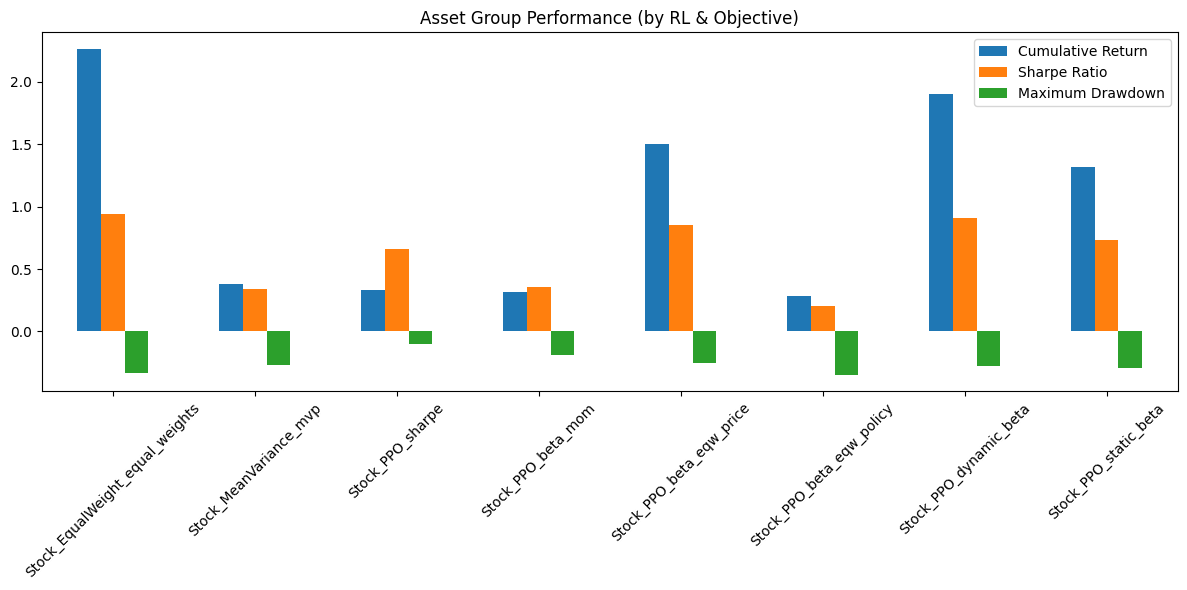

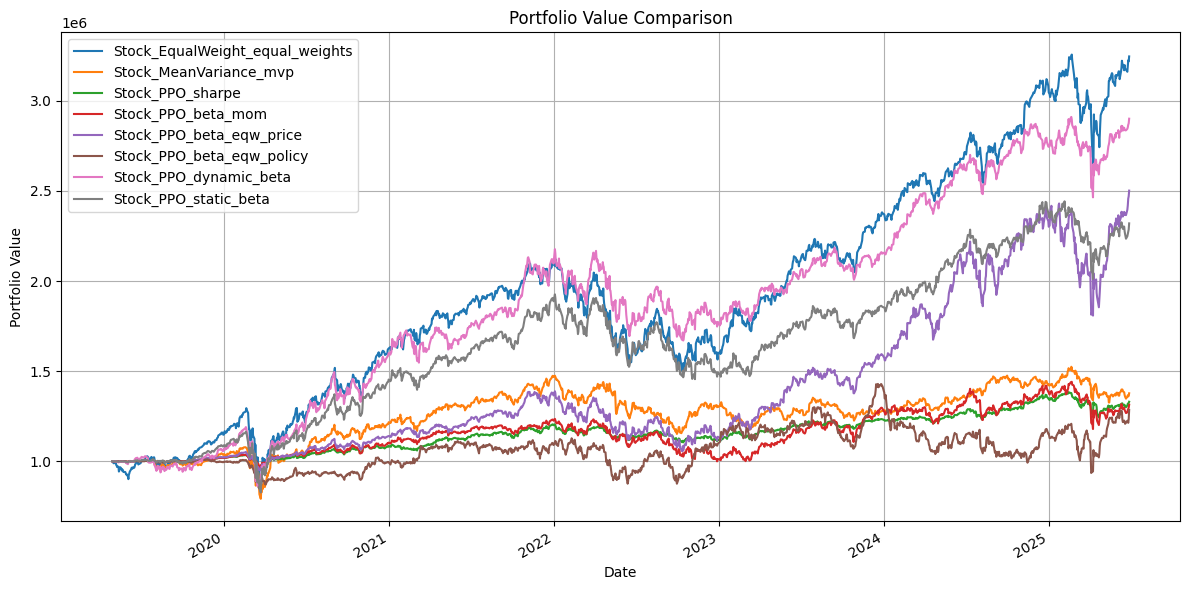


🔎 [Stock_PPO_sharpe vs Stock_PPO_beta_mom]
▶ t-test p-value: 0.9526 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.5244 → 유의미하지 않음

🔎 [Stock_PPO_sharpe vs Stock_PPO_beta_eqw_price]
▶ t-test p-value: 0.1474 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.0819 → 유의미하지 않음

🔎 [Stock_PPO_sharpe vs Stock_PPO_beta_eqw_policy]
▶ t-test p-value: 0.8893 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.7929 → 유의미하지 않음

🔎 [Stock_PPO_sharpe vs Stock_PPO_dynamic_beta]
▶ t-test p-value: 0.0996 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.0001 → 유의미함

🔎 [Stock_PPO_sharpe vs Stock_PPO_static_beta]
▶ t-test p-value: 0.2063 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.0026 → 유의미함
   Group Algorithm      CompareWith       t_p       u_p
0  Stock       PPO         beta_mom  0.952599  0.524399
1  Stock       PPO   beta_eqw_price  0.147356  0.081871
2  Stock       PPO  beta_eqw_policy  0.889319  0.792941
3  Stock       PPO     dynamic_beta  0.099643  0.000130
4  Stock       PPO      static_beta  0.206283  0.002563


In [ ]:
 # 실험 실행
results = {}
previous_group = None

for group, assets, algo_name, algo_class, objective in stock_experiments:
    key = f"{group}_{algo_name}_{objective}"
    print(f"▶ Running: {key}")
    try:
        results[key] = train_and_evaluate(assets, algo_class, objective)
    except Exception as e:
        print(f"Error in {key}: {str(e)}")
        results[key] = None
    # 그룹이 바뀔때만 기술통계 출력
    if previous_group != group:
        show_summary = True
        previous_group = group
    else:
        show_summary = False


# 성과 요약 (오류 제외)
valid_results = {k: v for k, v in results.items() if v is not None}
metrics_table = pd.DataFrame({k: performance_metrics(v) for k, v in valid_results.items()}).T
print(metrics_table)

# 성과 막대그래프
metrics_table[["Cumulative Return", "Sharpe Ratio", "Maximum Drawdown"]].plot(
    kind="bar", figsize=(12, 6), title="Asset Group Performance (by RL & Objective)"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 포트폴리오 가치 시계열 그래프
results_df = pd.DataFrame(valid_results)
results_df.plot(figsize=(12, 6), title="Portfolio Value Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.tight_layout()
plt.show()



# sharpe 를 baseline으로 하여 통계적으로 의미가 있는지 비교함
summary = []

for (group, assets, algo, model_cls, obj) in stock_experiments:
    if obj == "sharpe":
        continue  # baseline 제외

    base_key = f"{group}_{algo}_sharpe"
    compare_key = f"{group}_{algo}_{obj}"

    # Add check for None before calling compare_strategies
    if base_key in results and compare_key in results and results[base_key] is not None and results[compare_key] is not None:
        res = compare_strategies(results[base_key], results[compare_key], label1=base_key, label2=compare_key)
        summary.append({
            "Group": group,
            "Algorithm": algo,
            "CompareWith": obj,
            "t_p": res["t_p"],
            "u_p": res["u_p"]
        })

summary_df = pd.DataFrame(summary)
#import ace_tools as tools; tools.display_dataframe_to_user(name="Comparison Results", dataframe=summary_df)
print(summary_df)

암호자산 평가

▶ Running: Crypto_EqualWeight_equal_weights
▶ Running: Crypto_MeanVariance_mvp

[기술통계 요약: Price]
          count        mean         std        min         25%         50%  \
Ticker                                                                       
BNB-USD  1846.0    364.1718    195.5147    15.1853    244.0997    322.7530   
BTC-USD  1846.0  44575.8803  25693.6774  9045.3906  24191.0161  39403.7637   
ETH-USD  1846.0   2182.4931   1015.8011   222.9598   1579.7525   2052.6350   
SOL-USD  1846.0     80.1243     71.0398     0.5706     20.5924     42.7757   

                75%          max  
Ticker                            
BNB-USD    556.2794     750.2726  
BTC-USD  60791.5312  111673.2812  
ETH-USD   2961.4708    4812.0874  
SOL-USD    143.8059     261.8698  

[기술통계 요약: Returns]
          count    mean     std     min     25%     50%     75%     max
Ticker                                                                 
BNB-USD  1846.0  0.0029  0.0448 -0.3327 -0.0150  0.0013  0.0

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Crypto_PPO_beta_mom


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Crypto_PPO_beta_eqw_price


...

▶ Running: Crypto_PPO_dynamic_beta


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Crypto_PPO_static_beta


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


                                  Sharpe Ratio  Sortino Ratio  \
Crypto_EqualWeight_equal_weights      1.254438       1.739263   
Crypto_MeanVariance_mvp               0.983912       1.373160   
Crypto_PPO_sharpe                     0.434778       0.549912   
Crypto_PPO_beta_mom                   0.321171       0.403857   
Crypto_PPO_beta_eqw_price             0.261134       0.329547   
Crypto_PPO_beta_eqw_policy            0.277944       0.370880   
Crypto_PPO_dynamic_beta               0.677812       0.915729   
Crypto_PPO_static_beta                0.261134       0.329547   

                                  Cumulative Return  Annualized Return  \
Crypto_EqualWeight_equal_weights          63.183013           0.766042   
Crypto_MeanVariance_mvp                   16.289117           0.495355   
Crypto_PPO_sharpe                          1.032180           0.101642   
Crypto_PPO_beta_mom                        0.913463           0.092626   
Crypto_PPO_beta_eqw_price                  0

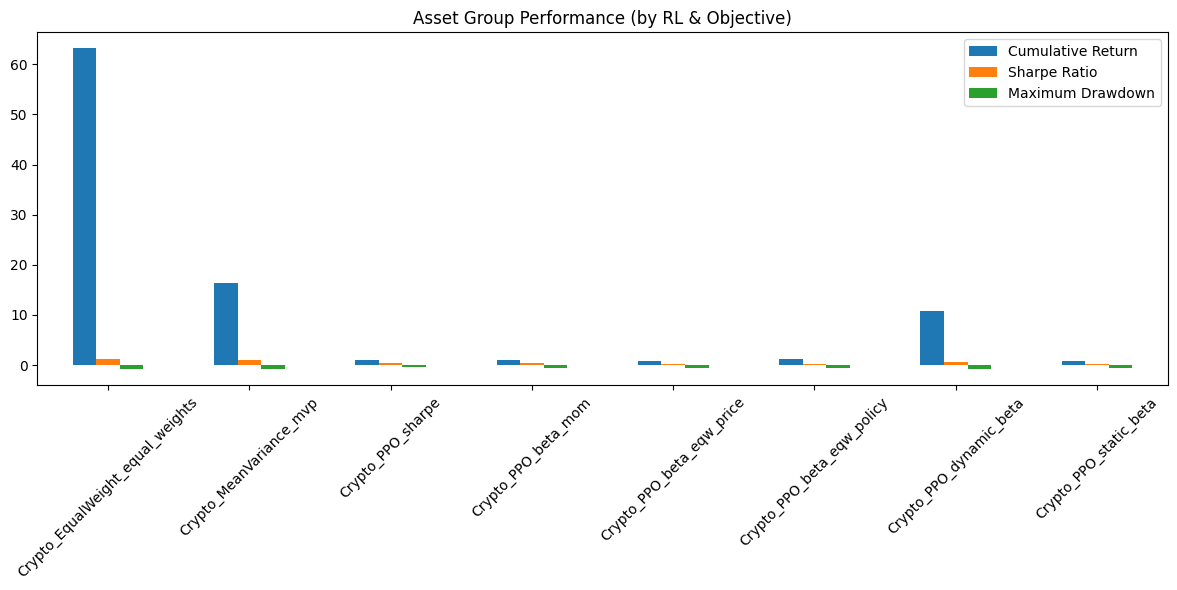

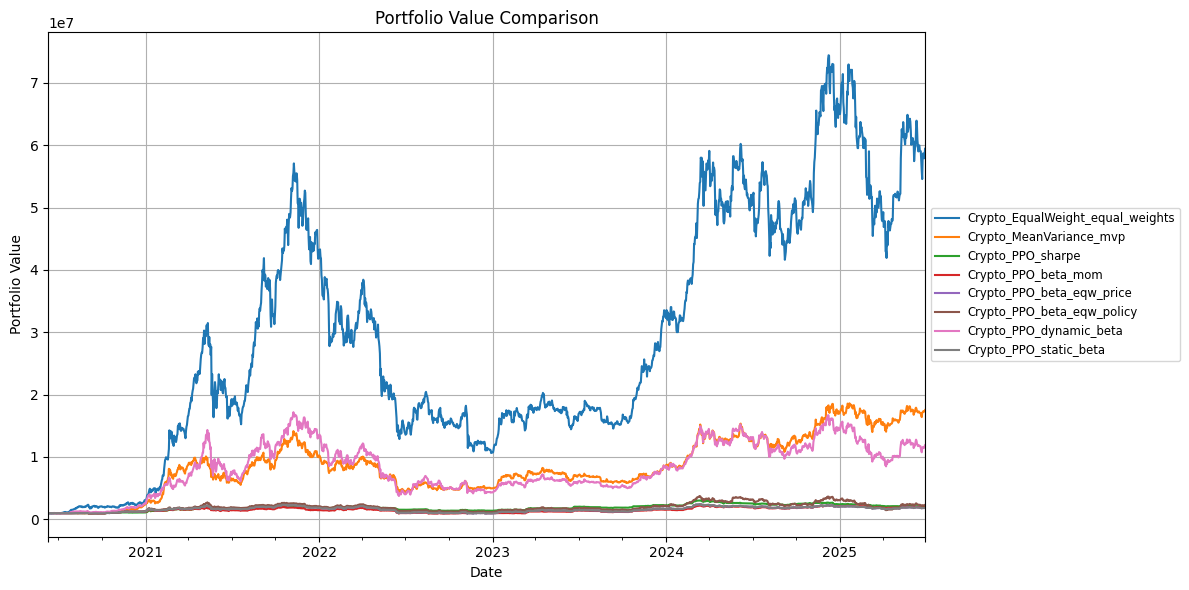


🔎 [Crypto_PPO_sharpe vs Crypto_PPO_beta_mom]
▶ t-test p-value: 0.9646 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.9872 → 유의미하지 않음

🔎 [Crypto_PPO_sharpe vs Crypto_PPO_beta_eqw_price]
▶ t-test p-value: 0.9440 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.7186 → 유의미하지 않음

🔎 [Crypto_PPO_sharpe vs Crypto_PPO_beta_eqw_policy]
▶ t-test p-value: 0.6430 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.3396 → 유의미하지 않음

🔎 [Crypto_PPO_sharpe vs Crypto_PPO_dynamic_beta]
▶ t-test p-value: 0.0969 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.0122 → 유의미함

🔎 [Crypto_PPO_sharpe vs Crypto_PPO_static_beta]
▶ t-test p-value: 0.9440 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.7186 → 유의미하지 않음
    Group Algorithm      CompareWith       t_p       u_p
0  Crypto       PPO         beta_mom  0.964601  0.987154
1  Crypto       PPO   beta_eqw_price  0.943961  0.718565
2  Crypto       PPO  beta_eqw_policy  0.643042  0.339634
3  Crypto       PPO     dynamic_beta  0.096928  0.012198
4  Crypto       PPO      static_beta  0.9439

In [ ]:
 # 실험 실행
results = {}
previous_group = None

for group, assets, algo_name, algo_class, objective in Crypto_experiments:
    key = f"{group}_{algo_name}_{objective}"
    print(f"▶ Running: {key}")
    try:
        results[key] = train_and_evaluate(assets, algo_class, objective)
    except Exception as e:
        print(f"Error in {key}: {str(e)}")
        results[key] = None
    # 그룹이 바뀔때만 기술통계 출력
    if previous_group != group:
        show_summary = True
        previous_group = group
    else:
        show_summary = False


# 성과 요약 (오류 제외)
valid_results = {k: v for k, v in results.items() if v is not None}
metrics_table = pd.DataFrame({k: performance_metrics(v) for k, v in valid_results.items()}).T
print(metrics_table)

# 성과 막대그래프
metrics_table[["Cumulative Return", "Sharpe Ratio", "Maximum Drawdown"]].plot(
    kind="bar", figsize=(12, 6), title="Asset Group Performance (by RL & Objective)"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 포트폴리오 가치 시계열 그래프
results_df = pd.DataFrame(valid_results)
ax = results_df.plot(figsize=(12, 6), title="Portfolio Value Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
# 🔽 범례를 오른쪽 바깥에 배치
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.tight_layout()
plt.show()



# sharpe 를 baseline으로 하여 통계적으로 의미가 있는지 비교함
summary = []

for (group, assets, algo, model_cls, obj) in Crypto_experiments:
    if obj == "sharpe":
        continue  # baseline 제외

    base_key = f"{group}_{algo}_sharpe"
    compare_key = f"{group}_{algo}_{obj}"

    # Add check for None before calling compare_strategies
    if base_key in results and compare_key in results and results[base_key] is not None and results[compare_key] is not None:
        res = compare_strategies(results[base_key], results[compare_key], label1=base_key, label2=compare_key)
        summary.append({
            "Group": group,
            "Algorithm": algo,
            "CompareWith": obj,
            "t_p": res["t_p"],
            "u_p": res["u_p"]
        })

summary_df = pd.DataFrame(summary)
#import ace_tools as tools; tools.display_dataframe_to_user(name="Comparison Results", dataframe=summary_df)
print(summary_df)

혼합자산

▶ Running: Mixed_EqualWeight_equal_weights
▶ Running: Mixed_MeanVariance_mvp

[기술통계 요약: Price]
          count        mean         std        min         25%         50%  \
Ticker                                                                       
AAPL     1846.0    165.2726     38.0275    81.6295    136.9675    163.1579   
AMZN     1846.0    156.1121     34.0217    81.8200    131.8325    159.7670   
BA       1846.0    192.3906     30.5584   115.8600    170.6050    192.8300   
BNB-USD  1846.0    364.1718    195.5147    15.1853    244.0997    322.7530   
BTC-USD  1846.0  44575.8803  25693.6774  9045.3906  24191.0161  39403.7637   
DIS      1846.0    119.2096     31.9121    78.0194     94.1020    109.6580   
ETH-USD  1846.0   2182.4931   1015.8011   222.9598   1579.7525   2052.6350   
GOOGL    1846.0    128.1512     31.7854    67.7209    103.1709    129.1010   
INTC     1846.0     37.1801     11.1096    18.1300     27.7785     36.3769   
JNJ      1846.0    149.1034      9.8674   119.5

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Mixed_PPO_beta_mom


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Mixed_PPO_beta_eqw_price


...

▶ Running: Mixed_PPO_dynamic_beta


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Mixed_PPO_static_beta


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


                                 Sharpe Ratio  Sortino Ratio  \
Mixed_EqualWeight_equal_weights      1.329621       1.718262   
Mixed_MeanVariance_mvp               0.398053       0.496888   
Mixed_PPO_sharpe                     0.402885       0.511777   
Mixed_PPO_beta_mom                   0.613420       0.781798   
Mixed_PPO_beta_eqw_price             0.101262       0.102051   
Mixed_PPO_beta_eqw_policy            0.402756       0.539513   
Mixed_PPO_dynamic_beta               1.120369       1.501412   
Mixed_PPO_static_beta                0.466656       0.599850   

                                 Cumulative Return  Annualized Return  \
Mixed_EqualWeight_equal_weights           4.531849           0.263340   
Mixed_MeanVariance_mvp                    0.353745           0.043686   
Mixed_PPO_sharpe                          0.669403           0.072463   
Mixed_PPO_beta_mom                        2.892997           0.203872   
Mixed_PPO_beta_eqw_price                  0.163277        

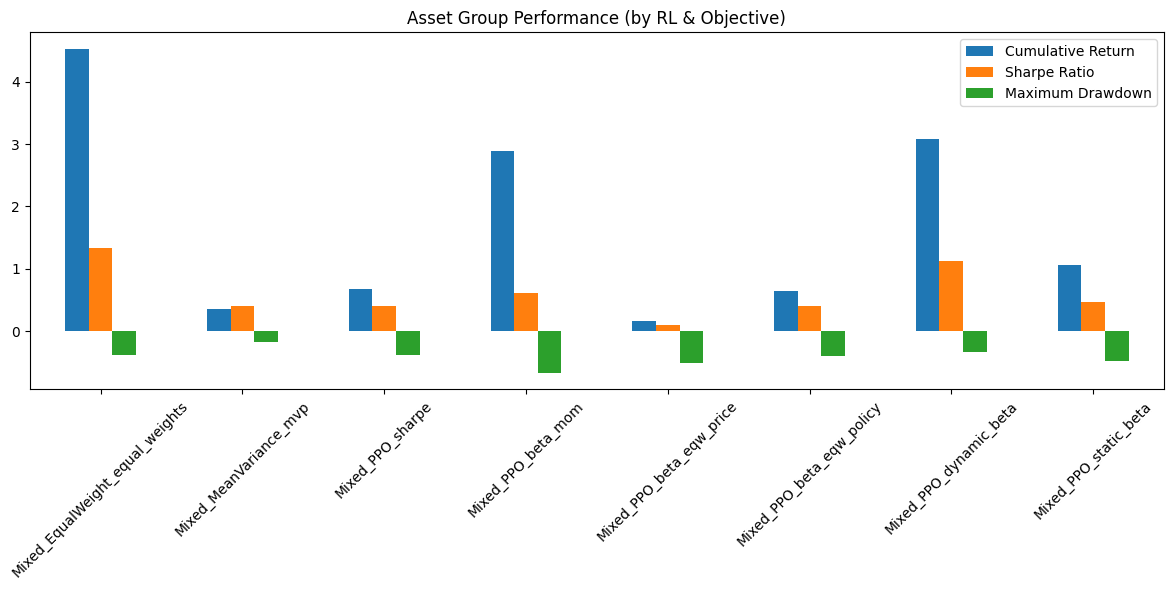

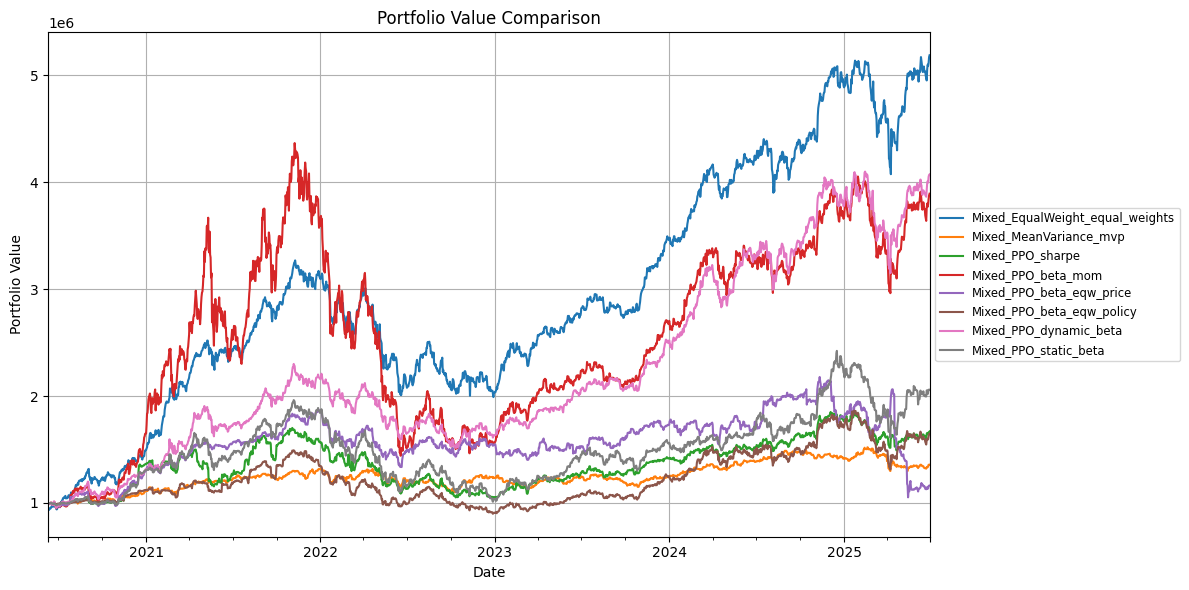


🔎 [Mixed_PPO_sharpe vs Mixed_PPO_beta_mom]
▶ t-test p-value: 0.2669 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.0401 → 유의미함

🔎 [Mixed_PPO_sharpe vs Mixed_PPO_beta_eqw_price]
▶ t-test p-value: 0.6665 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.5740 → 유의미하지 않음

🔎 [Mixed_PPO_sharpe vs Mixed_PPO_beta_eqw_policy]
▶ t-test p-value: 0.9780 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.6739 → 유의미하지 않음

🔎 [Mixed_PPO_sharpe vs Mixed_PPO_dynamic_beta]
▶ t-test p-value: 0.1999 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.1323 → 유의미하지 않음

🔎 [Mixed_PPO_sharpe vs Mixed_PPO_static_beta]
▶ t-test p-value: 0.7246 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.5460 → 유의미하지 않음
   Group Algorithm      CompareWith       t_p       u_p
0  Mixed       PPO         beta_mom  0.266942  0.040134
1  Mixed       PPO   beta_eqw_price  0.666456  0.574011
2  Mixed       PPO  beta_eqw_policy  0.977982  0.673881
3  Mixed       PPO     dynamic_beta  0.199903  0.132263
4  Mixed       PPO      static_beta  0.724578  0.545989


In [ ]:
 # 실험 실행
results = {}
previous_group = None

for group, assets, algo_name, algo_class, objective in Mixed_experiments:
    key = f"{group}_{algo_name}_{objective}"
    print(f"▶ Running: {key}")
    try:
        results[key] = train_and_evaluate(assets, algo_class, objective)
    except Exception as e:
        print(f"Error in {key}: {str(e)}")
        results[key] = None
    # 그룹이 바뀔때만 기술통계 출력
    if previous_group != group:
        show_summary = True
        previous_group = group
    else:
        show_summary = False


# 성과 요약 (오류 제외)
valid_results = {k: v for k, v in results.items() if v is not None}
metrics_table = pd.DataFrame({k: performance_metrics(v) for k, v in valid_results.items()}).T
print(metrics_table)

# 성과 막대그래프
metrics_table[["Cumulative Return", "Sharpe Ratio", "Maximum Drawdown"]].plot(
    kind="bar", figsize=(12, 6), title="Asset Group Performance (by RL & Objective)"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# 포트폴리오 가치 시계열 그래프
results_df = pd.DataFrame(valid_results)
ax = results_df.plot(figsize=(12, 6), title="Portfolio Value Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
# 🔽 범례를 오른쪽 바깥에 배치
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.tight_layout()
plt.show()


# sharpe 를 baseline으로 하여 통계적으로 의미가 있는지 비교함
summary = []

for (group, assets, algo, model_cls, obj) in Mixed_experiments:
    if obj == "sharpe":
        continue  # baseline 제외

    base_key = f"{group}_{algo}_sharpe"
    compare_key = f"{group}_{algo}_{obj}"

    # Add check for None before calling compare_strategies
    if base_key in results and compare_key in results and results[base_key] is not None and results[compare_key] is not None:
        res = compare_strategies(results[base_key], results[compare_key], label1=base_key, label2=compare_key)
        summary.append({
            "Group": group,
            "Algorithm": algo,
            "CompareWith": obj,
            "t_p": res["t_p"],
            "u_p": res["u_p"]
        })

summary_df = pd.DataFrame(summary)
#import ace_tools as tools; tools.display_dataframe_to_user(name="Comparison Results", dataframe=summary_df)
print(summary_df)

혼잡자산 모두

▶ Running: Mixed_EqualWeight_equal_weights
▶ Running: Mixed_MeanVariance_mvp

[기술통계 요약: Price]
          count        mean         std        min         25%         50%  \
Ticker                                                                       
AAPL     1846.0    165.2726     38.0275    81.6295    136.9675    163.1579   
AMZN     1846.0    156.1121     34.0217    81.8200    131.8325    159.7670   
BA       1846.0    192.3906     30.5584   115.8600    170.6050    192.8300   
BNB-USD  1846.0    364.1718    195.5147    15.1853    244.0997    322.7530   
BTC-USD  1846.0  44575.8803  25693.6774  9045.3906  24191.0161  39403.7637   
DIS      1846.0    119.2096     31.9121    78.0194     94.1020    109.6580   
ETH-USD  1846.0   2182.4931   1015.8011   222.9598   1579.7525   2052.6350   
GOOGL    1846.0    128.1512     31.7854    67.7209    103.1709    129.1010   
INTC     1846.0     37.1801     11.1096    18.1300     27.7785     36.3769   
JNJ      1846.0    149.1034      9.8674   119.5

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Mixed_PPO_dynamic_beta


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Mixed_PPO_static_beta


...

▶ Running: Mixed_TD3_dynamic_beta


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


▶ Running: Mixed_TD3_static_beta


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


                                 Sharpe Ratio  Sortino Ratio  \
Mixed_EqualWeight_equal_weights      1.329621       1.718262   
Mixed_MeanVariance_mvp               0.398053       0.496888   
Mixed_PPO_sharpe                     0.402885       0.511777   
Mixed_PPO_dynamic_beta               1.120369       1.501412   
Mixed_PPO_static_beta                0.466656       0.599850   
Mixed_SAC_sharpe                     0.644009       0.851758   
Mixed_SAC_dynamic_beta               0.790503       1.123864   
Mixed_SAC_static_beta                0.788288       1.119949   
Mixed_TD3_sharpe                     0.790167       1.113191   
Mixed_TD3_dynamic_beta               0.790637       1.116706   
Mixed_TD3_static_beta                0.789350       1.112765   

                                 Cumulative Return  Annualized Return  \
Mixed_EqualWeight_equal_weights           4.531849           0.263340   
Mixed_MeanVariance_mvp                    0.353745           0.043686   
Mixed_PPO_sh

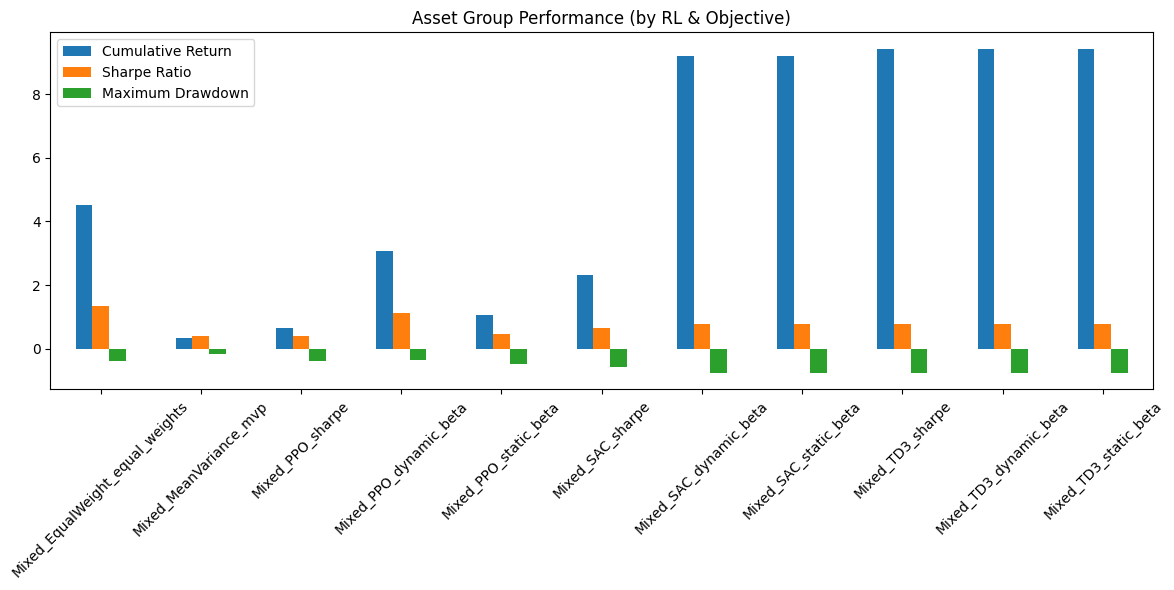

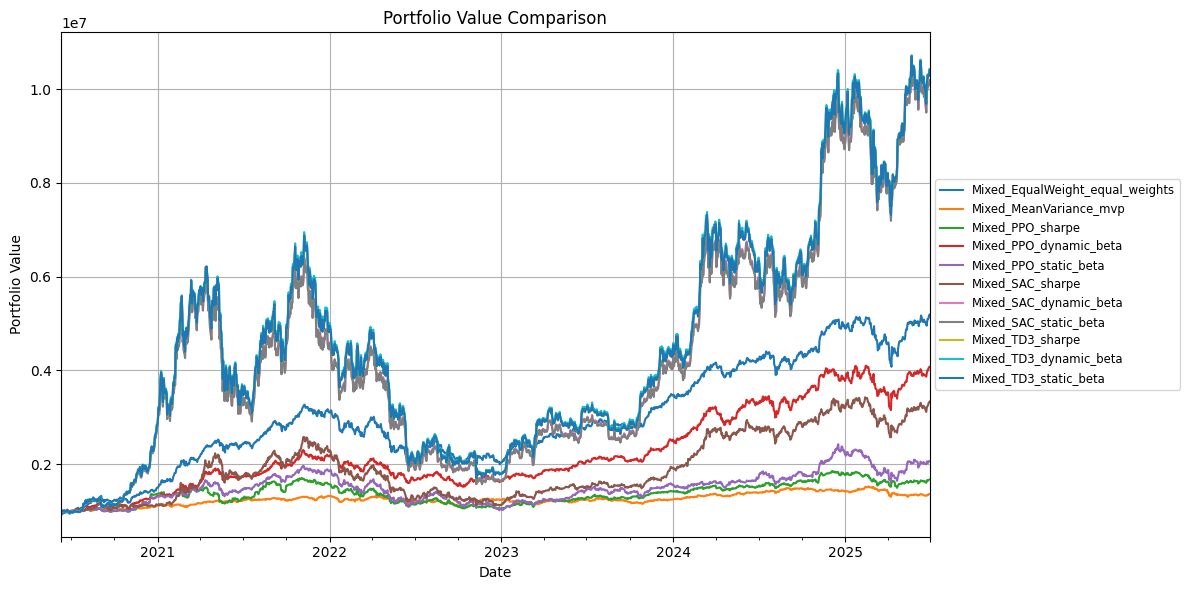


🔎 [Mixed_PPO_sharpe vs Mixed_PPO_dynamic_beta]
▶ t-test p-value: 0.1999 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.1323 → 유의미하지 않음

🔎 [Mixed_PPO_sharpe vs Mixed_PPO_static_beta]
▶ t-test p-value: 0.7246 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.5460 → 유의미하지 않음

🔎 [Mixed_SAC_sharpe vs Mixed_SAC_dynamic_beta]
▶ t-test p-value: 0.2644 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.7979 → 유의미하지 않음

🔎 [Mixed_SAC_sharpe vs Mixed_SAC_static_beta]
▶ t-test p-value: 0.2645 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.7975 → 유의미하지 않음

🔎 [Mixed_TD3_sharpe vs Mixed_TD3_dynamic_beta]
▶ t-test p-value: 0.9994 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.9889 → 유의미하지 않음

🔎 [Mixed_TD3_sharpe vs Mixed_TD3_static_beta]
▶ t-test p-value: 0.9998 → 유의미하지 않음
▶ Mann–Whitney U-test p-value: 0.9960 → 유의미하지 않음
   Group Algorithm   CompareWith       t_p       u_p
0  Mixed       PPO  dynamic_beta  0.199903  0.132263
1  Mixed       PPO   static_beta  0.724578  0.545989
2  Mixed       SAC  dynamic_beta  0.264418  0.

In [ ]:
 # 실험 실행
results = {}
previous_group = None

for group, assets, algo_name, algo_class, objective in Mixed_all_experiments:
    key = f"{group}_{algo_name}_{objective}"
    print(f"▶ Running: {key}")
    try:
        results[key] = train_and_evaluate(assets, algo_class, objective)
    except Exception as e:
        print(f"Error in {key}: {str(e)}")
        results[key] = None
    # 그룹이 바뀔때만 기술통계 출력
    if previous_group != group:
        show_summary = True
        previous_group = group
    else:
        show_summary = False


# 성과 요약 (오류 제외)
valid_results = {k: v for k, v in results.items() if v is not None}
metrics_table = pd.DataFrame({k: performance_metrics(v) for k, v in valid_results.items()}).T
print(metrics_table)

# 성과 막대그래프
metrics_table[["Cumulative Return", "Sharpe Ratio", "Maximum Drawdown"]].plot(
    kind="bar", figsize=(12, 6), title="Asset Group Performance (by RL & Objective)"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 포트폴리오 가치 시계열 그래프
results_df = pd.DataFrame(valid_results)
ax = results_df.plot(figsize=(12, 6), title="Portfolio Value Comparison")

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)

# 🔽 범례를 오른쪽 바깥에 배치
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')

plt.tight_layout()
plt.show()


# sharpe 를 baseline으로 하여 통계적으로 의미가 있는지 비교함
summary = []

for (group, assets, algo, model_cls, obj) in Mixed_all_experiments:
    if obj == "sharpe":
        continue  # baseline 제외

    base_key = f"{group}_{algo}_sharpe"
    compare_key = f"{group}_{algo}_{obj}"

    # Add check for None before calling compare_strategies
    if base_key in results and compare_key in results and results[base_key] is not None and results[compare_key] is not None:
        res = compare_strategies(results[base_key], results[compare_key], label1=base_key, label2=compare_key)
        summary.append({
            "Group": group,
            "Algorithm": algo,
            "CompareWith": obj,
            "t_p": res["t_p"],
            "u_p": res["u_p"]
        })

summary_df = pd.DataFrame(summary)
#import ace_tools as tools; tools.display_dataframe_to_user(name="Comparison Results", dataframe=summary_df)
print(summary_df)

In [ ]:
멈춰

In [ ]:
# XAI (SHAP 해석) 함수 추가
import shap
from sklearn.ensemble import RandomForestRegressor


def run_shap_feature_importance_with_summary(factors, returns, target_asset="BTC-USD", sample_size=500):
    """
    SHAP 분석을 통해 각 팩터가 수익률에 미치는 영향을 시각화하고,
    Mean |SHAP value| 기준으로 수치 요약 결과를 반환
    """
    # 데이터 정리
    y = returns[target_asset].dropna()
    X = factors.loc[y.index].copy()
    X = X.dropna()
    y = y.loc[X.index]

    # 샘플 수 제한
    if sample_size is not None and len(X) > sample_size:
        X, _, y, _ = train_test_split(X, y, train_size=sample_size, random_state=42)

    # 모델 학습
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)

    # SHAP 계산
    explainer = shap.Explainer(model.predict, X)
    shap_values = explainer(X)

    # 시각화 (beeswarm 형식)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X, plot_type="dot", show=True)

    # 📊 평균 SHAP 값 계산 (논문용 해석)
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    shap_importance = pd.DataFrame({
        "Factor": X.columns,
        "Mean|SHAP|": mean_abs_shap
    }).sort_values(by="Mean|SHAP|", ascending=False).reset_index(drop=True)

    print("\n[SHAP 팩터 중요도 요약 (Mean Absolute SHAP Values)]")
    print(shap_importance.to_string(index=False))

    return shap_importance

In [ ]:
def run_shap_feature_importance(factors, returns, target_asset="BTC-USD", sample_size=1000):
    try:
        # 1. 대상 자산에 해당하는 팩터 컬럼 선택
        if isinstance(factors.columns[0], tuple):
            target_cols = [col for col in factors.columns if col[0] == target_asset]
        else:
            target_cols = [col for col in factors.columns if str(col).startswith(target_asset)]

        if not target_cols:
            print(f"[Error] {target_asset} 관련 팩터 컬럼이 없습니다.")
            return

        # 2. X, y 구성
        X = factors[target_cols].dropna()
        y = returns[target_asset].loc[X.index]

        # 3. X 컬럼 이름을 문자열로 변환 (중요!!)
        if isinstance(X.columns[0], tuple):
            X.columns = ['_'.join(col) for col in X.columns]

        # 4. 샘플 수 제한
        if sample_size and len(X) > sample_size:
            X, _, y, _ = train_test_split(X, y, train_size=sample_size, random_state=42)

        # 5. 모델 학습
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X, y)

        # 6. SHAP 분석
        explainer = shap.Explainer(model, X)
        shap_values = explainer(X)

        # 7. SHAP summary plot
        shap.summary_plot(shap_values, X, plot_type="dot")

        # 8. 평균 SHAP 값 표 출력
        mean_shap = pd.DataFrame({
            "Factor": X.columns,
            "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
        }).sort_values(by="Mean |SHAP|", ascending=False)

        print(mean_shap.round(4))
        return mean_shap

    except Exception as e:
        print(f"[오류] {target_asset}에 대한 SHAP 실행 실패: {e}")


In [ ]:
def run_shap_feature_importance_all_factors(factors, returns, target_asset, sample_size=1000):
    try:
        # 1. 모든 factor를 사용
        X = factors.dropna()
        y = returns[target_asset].loc[X.index]

        # 🔐 모든 컬럼 이름을 문자열로 변환 (중요!)
        X.columns = X.columns.map(str)

        # 2. 샘플 수 제한
        if sample_size and len(X) > sample_size:
            X, _, y, _ = train_test_split(X, y, train_size=sample_size, random_state=42)

        # 3. 모델 학습
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X, y)

        # 4. SHAP 분석
        explainer = shap.Explainer(model, X)
        shap_values = explainer(X)

        # 5. 시각화
        shap.summary_plot(shap_values, X, plot_type="dot")

        # 6. 평균 SHAP값 테이블
        mean_shap = pd.DataFrame({
            "Factor": X.columns,
            "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
        }).sort_values(by="Mean |SHAP|", ascending=False)

        print(mean_shap.round(4))
        return mean_shap

    except Exception as e:
        print(f"[오류] {target_asset}에 대한 SHAP 실행 실패: {e}")


In [ ]:
def run_shap_beta_feature_importance(factors, returns, target_asset, sample_size=1000):
    try:
        # 1. factor에서 dropna
        X = factors.dropna()

        # 2. 컬럼 이름 정리 (튜플 → 문자열)
        X.columns = [
            f"{col[0]}_{col[1]}" if isinstance(col, tuple) else str(col)
            for col in X.columns
        ]

        # 3. beta 관련 factor만 선택
        beta_columns = [col for col in X.columns if 'beta' in col.lower()]
        X = X[beta_columns]

        # ✅ returns와의 공통 인덱스 추출
        common_index = X.index.intersection(returns[target_asset].dropna().index)
        X = X.loc[common_index]
        y = returns[target_asset].loc[common_index]

        # 🔐 모든 컬럼 이름을 문자열로 변환
        X.columns = X.columns.map(str)

        # 2. 샘플 수 제한
        if sample_size and len(X) > sample_size:
            X, _, y, _ = train_test_split(X, y, train_size=sample_size, random_state=42)

        # 3. 모델 학습
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X, y)

        # 4. SHAP 분석
        explainer = shap.Explainer(model, X)
        shap_values = explainer(X)

        # 5. 시각화
        shap.summary_plot(shap_values, X, plot_type="dot")

        # 6. 평균 SHAP값 정리
        mean_shap = pd.DataFrame({
            "Factor": X.columns,
            "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
        }).sort_values(by="Mean |SHAP|", ascending=False)

        print(mean_shap.round(4))
        return mean_shap

    except Exception as e:
        print(f"[오류] {target_asset}에 대한 SHAP(beta) 실행 실패: {e}")


In [ ]:
price, returns, factors = fetch_data(mixed_assets)

for asset in mixed_assets:
    print(f"\n=== SHAP 분석 시작: {asset} ===")
    run_shap_feature_importance(factors=factors, returns=returns, target_asset=asset, sample_size=500)


In [ ]:
# 자산별 종가를 가져와서 price_df 생성
# 데이터 다운로드 (MultiIndex 처리)
raw_data = yf.download(mixed_assets, start=start_date, end=end_date, group_by='ticker' , auto_adjust=False)
price_df = raw_data.xs("Adj Close", axis=1, level=1)
price_df = price_df.dropna(how='all')

# 수익률 계산
returns_df = price_df.pct_change().dropna()

# SHAP 결과 저장용 딕셔너리 초기화
shap_results_all = {}

In [ ]:
# ▶ 평균 수익률이 가장 높은 모델 선택
mean_returns = {k: v.mean() for k, v in results.items()}
best_model_key = max(mean_returns, key=mean_returns.get)
print(f"\n✅ 수익률이 가장 높은 모델: {best_model_key}")

# ▶ 해당 모델만 SHAP 분석 수행
shap_results_all = {}

for asset in mixed_assets:
    try:
        print(f"[SHAP 실행] 모델={best_model_key}, 자산={asset}")
        shap_df = run_shap_beta_feature_importance(
            factors=factors,
            returns=returns_df,  # 종목별 수익률 DataFrame
            target_asset=asset,
            sample_size=500
        )
        shap_results_all[f"{best_model_key}_{asset}"] = shap_df
    except Exception as e:
        print(f"[오류] {asset}에 대한 SHAP 실행 실패: {e}")


In [ ]:
# 자산별 종가를 가져와서 price_df 생성
# 데이터 다운로드 (MultiIndex 처리)
raw_data = yf.download(mixed_assets, start="2018-01-01", end="2024-12-31", group_by='ticker' , auto_adjust=False)
price_df = raw_data.xs("Adj Close", axis=1, level=1)
price_df = price_df.dropna(how='all')

# 수익률 계산
returns_df = price_df.pct_change().dropna()

# SHAP 결과 저장용 딕셔너리 초기화
shap_results_all = {}

for model_key, portfolio_returns in results.items():
    for asset in mixed_assets:
        try:
            print(f"[asset=]{asset} [model_key=]{model_key}")
            shap_df = run_shap_beta_feature_importance(
                factors=factors,
                returns=returns_df,  # ✅ 반드시 종목별 수익률 DataFrame
                target_asset=asset,
                sample_size=500
            )
            shap_results_all[f"{model_key}_{asset}"] = shap_df
        except Exception as e:
            print(f"[오류] {asset}에 대한 SHAP 실행 실패: {e}")